# Phase 8 — Transfer Learning (foundation-model test)

Freeze each of the three backbones produced so far:

| backbone | trained on | what it saw |
|----------|-----------|-------------|
| **SimCLR** | CIFAR-10 | images only, no labels (contrastive SSL) |
| **Supervised** | CIFAR-10 | images + 10-class labels (CE loss) |
| **Random** | — | never trained |

Then linear-probe them on two **new** datasets, using the FIXED probe
protocol from Phase 1/3 (Adam 1e-3, wd 1e-6, 100 epochs, bs 256).

This is where SSL is supposed to shine: supervised representations
specialize to CIFAR-10's 10 classes and throw away the rest, while SSL
representations are more general-purpose.


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR100, STL10
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    CIFAR10_MEAN, CIFAR10_STD,
    get_device, get_cifar_resnet18,
)

# Toggle: set True to run on a fraction (quick smoke).
SMOKE_TEST = False

cfg = dict(
    batch_size   = 256,
    epochs       = 5 if SMOKE_TEST else 100,
    lr           = 1e-3,
    weight_decay = 1e-6,
    seed         = 42,
    num_workers  = 0,
    data_root    = './data',
    feat_dir     = './results/features',
    ckpt_dir     = './models/transfer',
    results_path = 'results/transfer_learning_results.json' if not SMOKE_TEST else 'results/transfer_smoke_results.json',
    fig_path     = 'figures/transfer_learning_comparison.png' if not SMOKE_TEST else 'figures/transfer_smoke_comparison.png',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])
os.makedirs(cfg['feat_dir'], exist_ok=True)
os.makedirs(cfg['ckpt_dir'], exist_ok=True)

device = get_device()
print('Device:', device)
print('Config:', cfg)

# Backbones to evaluate — SSL, SL, Random
BACKBONES = {
    'simclr':     'models/simclr_baseline.pth',
    'supervised': 'models/supervised_baseline.pth',
    'random':     'models/random_baseline_backbone.pth',
}
# Datasets — STL-10 added only if its 2.5 GB tarball is fully downloaded.
# (Stanford's mirror is slow; we let an external curl fetch in the background.)
_stl_path = os.path.join(cfg['data_root'], 'stl10_binary.tar.gz')
_stl_ready = os.path.exists(_stl_path) and os.path.getsize(_stl_path) >= 2_600_000_000
if SMOKE_TEST:
    DATASETS = ['cifar100']
else:
    DATASETS = ['cifar100', 'stl10'] if _stl_ready else ['cifar100']
print('Datasets:', DATASETS, ' (stl10_ready=' + str(_stl_ready) + ')')


Device: privateuseone:0
Config: {'batch_size': 256, 'epochs': 100, 'lr': 0.001, 'weight_decay': 1e-06, 'seed': 42, 'num_workers': 0, 'data_root': './data', 'feat_dir': './results/features', 'ckpt_dir': './models/transfer', 'results_path': 'results/transfer_learning_results.json', 'fig_path': 'figures/transfer_learning_comparison.png'}
Datasets: ['cifar100', 'stl10']  (stl10_ready=True)


In [2]:
# --- Cell 2: Backbone Loader ---
# Every backbone is the modified ResNet-18 with fc=Identity (outputs 512-d).
# Supervised and SimCLR checkpoints wrap backbone.* inside a larger state dict;
# Random is already backbone-only.

def load_backbone(name: str, path: str) -> nn.Module:
    ck = torch.load(path, map_location='cpu', weights_only=False)
    bb = get_cifar_resnet18()
    if name == 'random':
        bb.load_state_dict(ck['state_dict'])
    else:
        # state_dict keys are prefixed with 'backbone.' in both SimCLR and Supervised
        state = ck['model_state']
        bb_state = {k[len('backbone.'):]: v for k, v in state.items() if k.startswith('backbone.')}
        missing, unexpected = bb.load_state_dict(bb_state, strict=False)
        print(f'  [{name}] missing={len(missing)} unexpected={len(unexpected)}')
    for p in bb.parameters(): p.requires_grad = False
    bb.eval()
    return bb.to(device)

# Quick sanity load
backbones = {}
for name, path in BACKBONES.items():
    assert os.path.exists(path), f'missing backbone checkpoint: {path}'
    print(f'Loading {name} <- {path}')
    backbones[name] = load_backbone(name, path)
print('all backbones loaded.')


Loading simclr <- models/simclr_baseline.pth
  [simclr] missing=0 unexpected=0
Loading supervised <- models/supervised_baseline.pth
  [supervised] missing=0 unexpected=0
Loading random <- models/random_baseline_backbone.pth
all backbones loaded.


In [3]:
# --- Cell 3: Datasets (resize + normalize with CIFAR-10 stats) ---
# Per the PDF: resize everything to 32x32 and normalize with CIFAR-10 stats so
# the probe comparison is apples-to-apples.

transfer_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

def get_splits(name: str):
    if name == 'cifar100':
        tr = CIFAR100(cfg['data_root'], train=True,  download=True, transform=transfer_transform)
        te = CIFAR100(cfg['data_root'], train=False, download=True, transform=transfer_transform)
        n_classes = 100
    elif name == 'stl10':
        # STL-10 has 5000 labeled train, 8000 test, 10 classes, native 96x96.
        # Large (~2.6 GB) — if the download keeps failing, pre-fetch manually:
        #   curl -L -o data/stl10_binary.tar.gz -C - http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz
        # and torchvision will verify md5 and extract on next run.
        tr = STL10(cfg['data_root'], split='train', download=True, transform=transfer_transform)
        te = STL10(cfg['data_root'], split='test',  download=True, transform=transfer_transform)
        n_classes = 10
    else:
        raise ValueError(name)
    return tr, te, n_classes

# Skip datasets that fail to download/verify — keeps smoke-test usable even if
# one dataset is temporarily unreachable.
info = {}
available_datasets = []
for name in DATASETS:
    try:
        tr, te, k = get_splits(name)
        info[name] = dict(train=tr, test=te, n_classes=k)
        available_datasets.append(name)
        print(f'{name:10s} | train={len(tr):6d} | test={len(te):6d} | classes={k}')
    except Exception as e:
        print(f'{name:10s} | SKIPPED ({type(e).__name__}: {e})')

DATASETS = available_datasets  # shadow so downstream cells only use what loaded
if not DATASETS:
    raise RuntimeError('No transfer datasets available — check network / disk.')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
cifar100   | train= 50000 | test= 10000 | classes=100
Using downloaded and verified file: ./data\stl10_binary.tar.gz
Extracting ./data\stl10_binary.tar.gz to ./data
Files already downloaded and verified
stl10      | train=  5000 | test=  8000 | classes=10


In [4]:
# --- Cell 4: Feature extraction (one-time, cached to disk) ---
# Each (dataset, backbone, split) combination is extracted once and saved to
# disk. Subsequent runs pick up from cache. This is a big speedup since the
# backbones are frozen — features never change across epochs.

@torch.no_grad()
def extract_features(backbone: nn.Module, dataset) -> tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(dataset, batch_size=512, shuffle=False,
                        num_workers=cfg['num_workers'], pin_memory=False)
    feats, labels = [], []
    for x, y in tqdm(loader, desc='extracting', leave=False):
        x = x.to(device)
        h = backbone(x).cpu()
        feats.append(h); labels.append(y)
    return torch.cat(feats), torch.cat(labels)

def feat_cache_path(ds: str, bb: str, split: str) -> str:
    return os.path.join(cfg['feat_dir'], f'{ds}_{bb}_{split}.pt')

for ds_name in DATASETS:
    tr, te, _ = info[ds_name]['train'], info[ds_name]['test'], info[ds_name]['n_classes']
    for bb_name, bb in backbones.items():
        for split_name, split_ds in [('train', tr), ('test', te)]:
            path = feat_cache_path(ds_name, bb_name, split_name)
            if os.path.exists(path):
                print(f'cached: {path}')
                continue
            t0 = time.time()
            feats, labels = extract_features(bb, split_ds)
            torch.save({'features': feats, 'labels': labels}, path)
            print(f'saved  : {path}  feats={tuple(feats.shape)}  ({time.time()-t0:.1f}s)')

print('feature extraction complete.')


cached: ./results/features\cifar100_simclr_train.pt
cached: ./results/features\cifar100_simclr_test.pt
cached: ./results/features\cifar100_supervised_train.pt
cached: ./results/features\cifar100_supervised_test.pt
cached: ./results/features\cifar100_random_train.pt
cached: ./results/features\cifar100_random_test.pt


extracting:   0%|          | 0/10 [00:00<?, ?it/s]

saved  : ./results/features\stl10_simclr_train.pt  feats=(5000, 512)  (3.3s)


extracting:   0%|          | 0/16 [00:00<?, ?it/s]

saved  : ./results/features\stl10_simclr_test.pt  feats=(8000, 512)  (2.1s)


...

saved  : ./results/features\stl10_supervised_test.pt  feats=(8000, 512)  (2.1s)


extracting:   0%|          | 0/10 [00:00<?, ?it/s]

saved  : ./results/features\stl10_random_train.pt  feats=(5000, 512)  (1.3s)


extracting:   0%|          | 0/16 [00:00<?, ?it/s]

saved  : ./results/features\stl10_random_test.pt  feats=(8000, 512)  (2.0s)
feature extraction complete.


In [5]:
# --- Cell 5: Linear probe on cached features (resumable per-combo) ---

def run_probe(ds_name: str, bb_name: str, n_classes: int,
              epochs: int = None, force_restart: bool = False) -> dict:
    epochs = epochs or cfg['epochs']
    # Load cached features
    tr = torch.load(feat_cache_path(ds_name, bb_name, 'train'), map_location='cpu', weights_only=False)
    te = torch.load(feat_cache_path(ds_name, bb_name, 'test'),  map_location='cpu', weights_only=False)
    tr_feats, tr_labels = tr['features'], tr['labels']
    te_feats, te_labels = te['features'], te['labels']
    # Ensure long labels (STL-10 returns int64 already, but be safe)
    tr_labels = tr_labels.long(); te_labels = te_labels.long()

    train_loader = DataLoader(TensorDataset(tr_feats, tr_labels),
                              batch_size=cfg['batch_size'], shuffle=True,
                              num_workers=0, pin_memory=False, drop_last=False)
    # Test: keep on CPU, move per batch
    test_loader = DataLoader(TensorDataset(te_feats, te_labels),
                             batch_size=1024, shuffle=False, num_workers=0, pin_memory=False)

    torch.manual_seed(cfg['seed'])   # deterministic classifier init per combo
    classifier = nn.Linear(tr_feats.shape[1], n_classes).to(device)
    optimizer  = torch.optim.Adam(classifier.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}
    start_epoch = 1

    ckpt_path = os.path.join(cfg['ckpt_dir'], f'{ds_name}_{bb_name}.pth')
    if (not force_restart) and os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        classifier.load_state_dict(ck['classifier_state']); classifier.to(device)
        optimizer.load_state_dict(ck['optimizer_state'])
        log = ck['log']
        start_epoch = ck['epoch'] + 1
        print(f"  [{ds_name}/{bb_name}] RESUMING from epoch {start_epoch}", flush=True)

    @torch.no_grad()
    def _eval():
        classifier.eval()
        correct = total = 0
        for h, y in test_loader:
            h, y = h.to(device), y.to(device)
            pred = classifier(h).argmax(1)
            correct += (pred == y).sum().item(); total += y.size(0)
        return correct/total

    for epoch in range(start_epoch, epochs+1):
        classifier.train()
        loss_sum = corr = tot = 0
        for h, y in train_loader:
            h, y = h.to(device), y.to(device)
            logits = classifier(h)
            loss = F.cross_entropy(logits, y)
            optimizer.zero_grad(set_to_none=True)
            loss.backward(); optimizer.step()
            loss_sum += float(loss.detach().cpu()) * y.size(0)
            corr += (logits.argmax(1) == y).sum().item()
            tot += y.size(0)
        train_loss = loss_sum/tot; train_acc = corr/tot; test_acc = _eval()
        log['epoch'].append(epoch); log['train_loss'].append(train_loss)
        log['train_acc'].append(train_acc); log['test_acc'].append(test_acc)
        # atomic checkpoint
        tmp = ckpt_path + '.tmp'
        torch.save({'epoch': epoch, 'classifier_state': classifier.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'log': log}, tmp)
        os.replace(tmp, ckpt_path)

    return {
        'final_test_acc': log['test_acc'][-1],
        'best_test_acc':  max(log['test_acc']),
        'curve':          log,
    }

print('probe routine ready.')


probe routine ready.


In [6]:
# --- Cell 6: Run all (dataset, backbone) combinations ---
t_total = time.time()
results = {}
for ds_name in DATASETS:
    n_classes = info[ds_name]['n_classes']
    results[ds_name] = {}
    for bb_name in BACKBONES:
        t0 = time.time()
        print(f'>>> {ds_name} / {bb_name}  (n_classes={n_classes})', flush=True)
        r = run_probe(ds_name, bb_name, n_classes)
        results[ds_name][bb_name] = r
        print(f'    final={r["final_test_acc"]*100:.2f}%  best={r["best_test_acc"]*100:.2f}%  ({time.time()-t0:.1f}s)', flush=True)

# Persist
os.makedirs('results', exist_ok=True)
with open(cfg['results_path'], 'w') as f: json.dump(results, f, indent=2)
print(f'\nAll probes done in {(time.time()-t_total)/60:.1f} min')
print('Saved', cfg['results_path'])


>>> cifar100 / simclr  (n_classes=100)
  [cifar100/simclr] RESUMING from epoch 101
    final=49.72%  best=50.07%  (0.1s)
>>> cifar100 / supervised  (n_classes=100)
  [cifar100/supervised] RESUMING from epoch 101
    final=48.51%  best=48.84%  (0.1s)
>>> cifar100 / random  (n_classes=100)
  [cifar100/random] RESUMING from epoch 101
    final=18.80%  best=19.48%  (0.1s)
>>> stl10 / simclr  (n_classes=10)


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


    final=74.70%  best=74.76%  (11.2s)
>>> stl10 / supervised  (n_classes=10)
    final=78.42%  best=78.77%  (10.9s)
>>> stl10 / random  (n_classes=10)
    final=36.73%  best=37.40%  (11.4s)

All probes done in 0.6 min
Saved results/transfer_learning_results.json


In [7]:
# --- Cell 7: Results table + within-dataset comparison ---
# Also pull in the CIFAR-10 probe results for a unified picture.

def _load(path, *keys):
    if not os.path.exists(path): return None
    d = json.loads(Path(path).read_text())
    for k in keys:
        if d is None: return None
        d = d.get(k) if isinstance(d, dict) else None
    return d

cifar10_results = {
    'random':     _load('results/random_baseline_linear_probe.json', 'best_test_acc'),
    'simclr':     _load('results/simclr_baseline_linear_probe.json', 'best_test_acc'),
    'supervised': None,  # for CIFAR-10, the supervised model IS the full classifier, not a probe
}
sl_log = _load('results/supervised_baseline_log.json', 'test_acc')
if isinstance(sl_log, list): cifar10_results['supervised'] = max(sl_log)

order = ['random', 'simclr', 'supervised']
header = f"{'dataset':<12}  {'random':>10}  {'simclr':>10}  {'supervised':>12}"
print('Test accuracy (best)')
print('=' * len(header))
print(header)
print('-' * len(header))
# CIFAR-10 row (the training distribution)
def fmt(x): return f'{x*100:.2f}%' if x is not None else '    n/a '
print(f"{'cifar10 *':<12}  {fmt(cifar10_results['random']):>10}  {fmt(cifar10_results['simclr']):>10}  {fmt(cifar10_results['supervised']):>12}")
for ds_name in DATASETS:
    row = results[ds_name]
    r = row['random']['best_test_acc']
    s = row['simclr']['best_test_acc']
    l = row['supervised']['best_test_acc']
    print(f"{ds_name:<12}  {fmt(r):>10}  {fmt(s):>10}  {fmt(l):>12}")
print()
print('* CIFAR-10 row: random & simclr are linear probes, supervised is end-to-end.')
print('  All others: linear probe on frozen backbone with FIXED protocol.')


Test accuracy (best)
dataset           random      simclr    supervised
--------------------------------------------------
cifar10 *         41.76%      86.70%        92.54%
cifar100          19.48%      50.07%        48.84%
stl10             37.40%      74.76%        78.77%

* CIFAR-10 row: random & simclr are linear probes, supervised is end-to-end.
  All others: linear probe on frozen backbone with FIXED protocol.


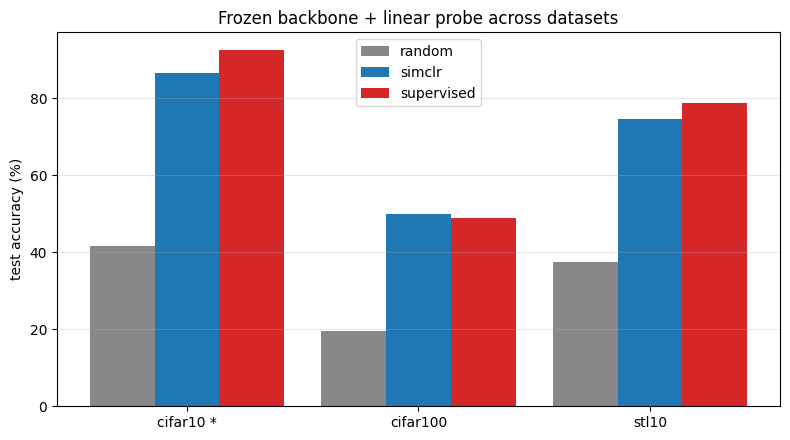

Saved figures/transfer_learning_comparison.png


In [8]:
# --- Cell 8: Grouped bar chart ---
import numpy as np

ds_names = ['cifar10 *'] + list(DATASETS)
sl_cifar10 = cifar10_results['supervised']
row_vals = {
    'random':     [cifar10_results['random']]     + [results[d]['random']['best_test_acc']     for d in DATASETS],
    'simclr':     [cifar10_results['simclr']]     + [results[d]['simclr']['best_test_acc']     for d in DATASETS],
    'supervised': [sl_cifar10]                    + [results[d]['supervised']['best_test_acc'] for d in DATASETS],
}

x = np.arange(len(ds_names))
width = 0.28
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {'random': '#888888', 'simclr': '#1f77b4', 'supervised': '#d62728'}
for i, bb in enumerate(['random', 'simclr', 'supervised']):
    vals = [v*100 if v is not None else 0 for v in row_vals[bb]]
    ax.bar(x + (i-1)*width, vals, width, label=bb, color=colors[bb])

ax.set_xticks(x)
ax.set_xticklabels(ds_names)
ax.set_ylabel('test accuracy (%)')
ax.set_title('Frozen backbone + linear probe across datasets')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig(cfg['fig_path'], dpi=150)
plt.show()
print('Saved', cfg['fig_path'])
